In [32]:
import math
import os
import csv
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [35]:
SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62
         count                           mean                  min                  25%                  50%                  75%  \
date      4320  2025-03-31 23:29:59.999999744  2025-01-01 00:00:00  2025-02-14 23:45:00  2025-03-31 23:30:00  2025-05-15 23:15:00   
target  4320.0                      135.60584                 69.1             120.5375              135.835              150.625   

                        max        std  
date    2025-06-29 23:00:00        NaN  
target                210.1  21.384633  
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00


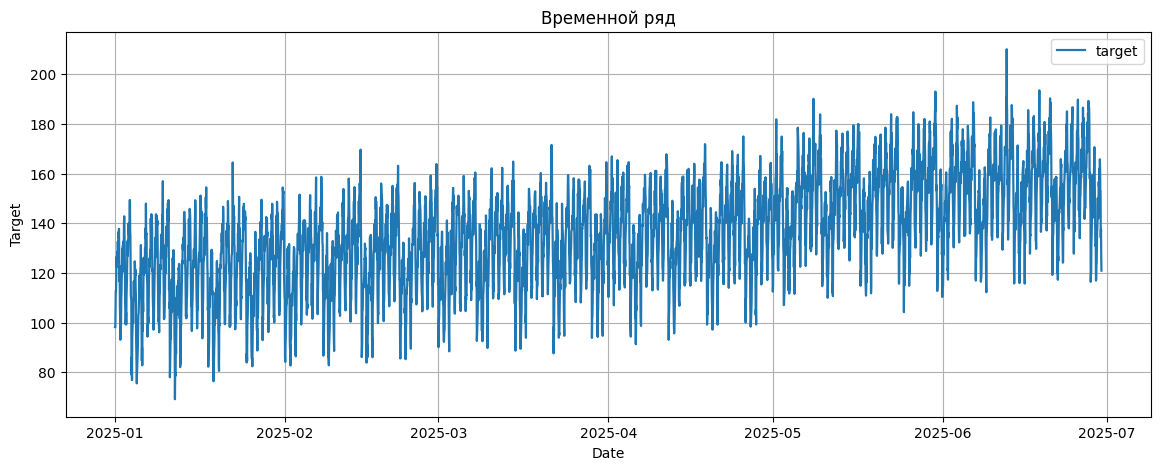

In [21]:
df = pd.read_csv("data/S12-hw-dataset.csv")
df['date'] = pd.to_datetime(df['date'])

print(df.head())
print(df.describe(include="all").T) # показывает число записей и пропусков
print(f"Диапазон дат: {df["date"].min()} - {df["date"].max()}")

fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.6, label="target")
ax.set_title("Временной ряд")
ax.set_ylabel("Target")
ax.set_xlabel("Date")
ax.legend()
plt.show()

Ряд имеет восходящий тренд с периодическими недельными повышениями значения target. Присутствует шум и резкие скачки.

In [22]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70  # 70% для обучения
    val_frac: float = 0.15    # 15% для валидации, остальное для теста

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()          # Ранний период
    val_df = df.iloc[train_end:val_end].copy()     # Средний период
    test_df = df.iloc[val_end:].copy()             # Поздний период
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (3024, 2), 2025-01-01 -> 2025-05-06
val  : (648, 2), 2025-05-07 -> 2025-06-02
test : (648, 2), 2025-06-03 -> 2025-06-29


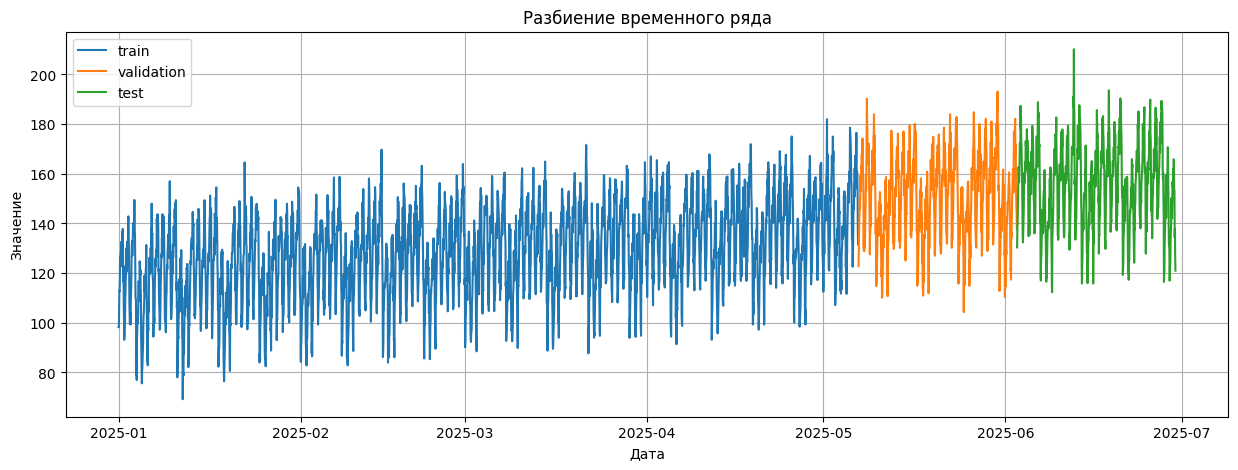

In [40]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Разбиение временного ряда")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig("artifacts/figures/series_split.png")
plt.show()

Random split некорретен для временных рядов, потому что он перемешивает значения. Моделоь будет учиться на смешанных данных из прошлого и будущего, что не соответствует задаче предсказания будущего используя только прошлое.

In [29]:
def add_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    out["dayofweek"] = out["date"].dt.dayofweek

    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    return out

features_df = add_features(df)
features_df = features_df.dropna().reset_index(drop=True)
features_df.head(20)

,date,target,dayofweek,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 14:00:00,128.87,2,125.04,126.01,98.14,126.445714,3.275621
1,2025-01-01 15:00:00,136.40,2,128.87,122.38,98.07,126.854286,3.388632
2,2025-01-01 16:00:00,133.85,2,136.40,128.28,104.70,128.857143,4.318919
3,2025-01-01 17:00:00,137.71,2,133.85,124.43,112.81,129.652857,4.691868
4,2025-01-01 18:00:00,126.32,2,137.71,126.35,112.62,131.550000,4.907936
5,2025-01-01 19:00:00,116.59,2,126.32,132.63,117.29,131.545714,4.913244
6,2025-01-01 20:00:00,122.83,2,116.59,125.04,126.50,129.254286,7.422746
7,2025-01-01 21:00:00,106.54,2,122.83,128.87,126.01,128.938571,7.674595
8,2025-01-01 22:00:00,101.72,2,106.54,136.40,122.38,125.748571,11.429896
9,2025-01-01 23:00:00,93.04,2,101.72,133.85,128.28,120.794286,13.391289


In [31]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "dayofweek",
    "lag_1", "lag_7", "lag_14", 
    "rolling_mean_7", "rolling_std_7"
]

target_col = "target"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (3014, 6) | y_train: (3014,)
X_val:   (646, 6) | y_val:   (646,)
X_test:  (646, 6) | y_test:  (646,)


In [37]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)


def evaluate_regression(y_true, y_pred) -> dict:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
    }


def save_results(res: dict, file="artifacts/runs.csv"):
    fieldnames = [
        "experiment_id", "task", "dataset", "seed", "split_summary", "window_size", "horizon", "model_summary",
        "features_summary", "scaler", "optimizer", "lr", "epochs_trained", "best_val_mae", "best_val_rmse", "best_val_mape",
        "test_mae", "test_rmse", "test_mape", "notes"
    ]

    file_exists = os.path.isfile(file)

    with open(file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        if not file_exists:
            writer.writeheader()
        
        writer.writerow(res)

In [ ]:
experiment_id = "B1"

val_pred_naive = val_feat["lag_1"].to_numpy()
metrics_b1 = evaluate_regression(y_val, val_pred_naive)
save_results({
    "experiment_id": experiment_id, 
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "temporal split 70/15/15", 
    "window_size": "",
    "horizon": "", 
    "model_summary": "naive-last",
    "features_summary": "dayofweek, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7", 
    "scaler": "", 
    "optimizer": "", 
    "lr": "", 
    "epochs_trained": "", 
    "best_val_mae": metrics_b1['MAE'], 
    "best_val_rmse": metrics_b1['RMSE'], 
    "best_val_mape": metrics_b1['MAPE'],
    "test_mae" : "",
    "test_rmse" : "",
    "test_mape": "", 
    "notes": ""
})

In [43]:
experiment_id = "B2"

val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
metrics_b2 = evaluate_regression(y_val, val_pred_ma7)
save_results({
    "experiment_id": experiment_id, 
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "temporal split 70/15/15", 
    "window_size": "7",
    "horizon": "", 
    "model_summary": "moving-average",
    "features_summary": "dayofweek, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7", 
    "scaler": "", 
    "optimizer": "", 
    "lr": "", 
    "epochs_trained": "", 
    "best_val_mae": metrics_b2['MAE'], 
    "best_val_rmse": metrics_b2['RMSE'], 
    "best_val_mape": metrics_b2['MAPE'],
    "test_mae" : "",
    "test_rmse" : "",
    "test_mape": "", 
    "notes": ""
})